# Machine Learning 3 - Support Vector Machines

A SVM classifier builds a set of hyper-planes to try and separate the data by maximizing the distance between the borders and the data points.

![SVM](http://scikit-learn.org/stable/_images/sphx_glr_plot_separating_hyperplane_0011.png "Decision border in an SVM")

This separation is generally not possible to achieve in the original data space. Therefore, the first step of the SVM is to project the data into a high or infinite dimensions space in which this linear separation can be done. The projection can be done with linear, polynomial, or more comonly "RBF" kernels.

In [1]:
from lab_tools import CIFAR10, evaluate_classifier, get_hog_image

dataset = CIFAR10('CIFAR10/')

Pre-loading training data
Pre-loading test data


**Build a simple SVM** using [the SVC (Support Vector Classfiication) from sklearn](http://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC). 
**Train** it on the CIFAR dataset.

In [3]:
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold

# -- Your code here -- #

X_train = dataset.train["hog"]
X_test = dataset.test["hog"]
y_train = dataset.train["labels"]
y_test = dataset.test["labels"]
clf = SVC()
clf.fit(X=X_train, y=y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


**Explore the classifier**. How many support vectors are there? What are support vectors?

In [4]:
#all_support_vectors = clf.support_vectors_ #Each line = 1 "Support Vector" ; 1024 columns forming a 32x32 image 
#vectors_per_class = clf.n_support_ #Number of "Support Vector" for each class

# -- Your code here -- #
all_support_vectors = clf.support_vectors_ #Each line = 1 "Support Vector" ; 1024 columns forming a 32x32 image 
vectors_per_class = clf.n_support_ #Number of "Support Vector" for each class


In [5]:
print(all_support_vectors.shape)
print(vectors_per_class.shape)

(8675, 256)
(3,)


**Try to find the best "C" (error penalty) and "gamma" parameters** using cross-validation. What influence does "C" have on the number of support vectors?

In [9]:
# -- Your code here -- #
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
import numpy as np

# Study of C
c_vals = [0.001, 0.01, 0.1, 1, 5, 10, 50, 100]
all_splits_score = []
#all_splits_all_sv = []
#all_splits_per_class_sv = []

for c in c_vals:
    clf = SVC(C=c)
    scores = cross_val_score(estimator=clf, X=X_train, y=y_train, cv=10)
    all_splits_score.append(scores)
    #all_support_vectors = clf.support_vectors_  
    #vectors_per_class = clf.n_support_
    print(f"C = {c} : accuracy = {np.mean(scores):.04f} +/- {np.std(scores):.04f}") #,\tall_support_vectors : {clf.support_vectors_.shape},\tsupport vectors per class : {clf.n_support_.shape}")
    

C = 0.001 : accuracy = 0.6859 +/- 0.0067
C = 0.01 : accuracy = 0.7083 +/- 0.0100
C = 0.1 : accuracy = 0.7722 +/- 0.0130
C = 1 : accuracy = 0.8162 +/- 0.0104
C = 5 : accuracy = 0.8275 +/- 0.0114
C = 10 : accuracy = 0.8258 +/- 0.0096
C = 50 : accuracy = 0.8255 +/- 0.0096
C = 100 : accuracy = 0.8255 +/- 0.0096


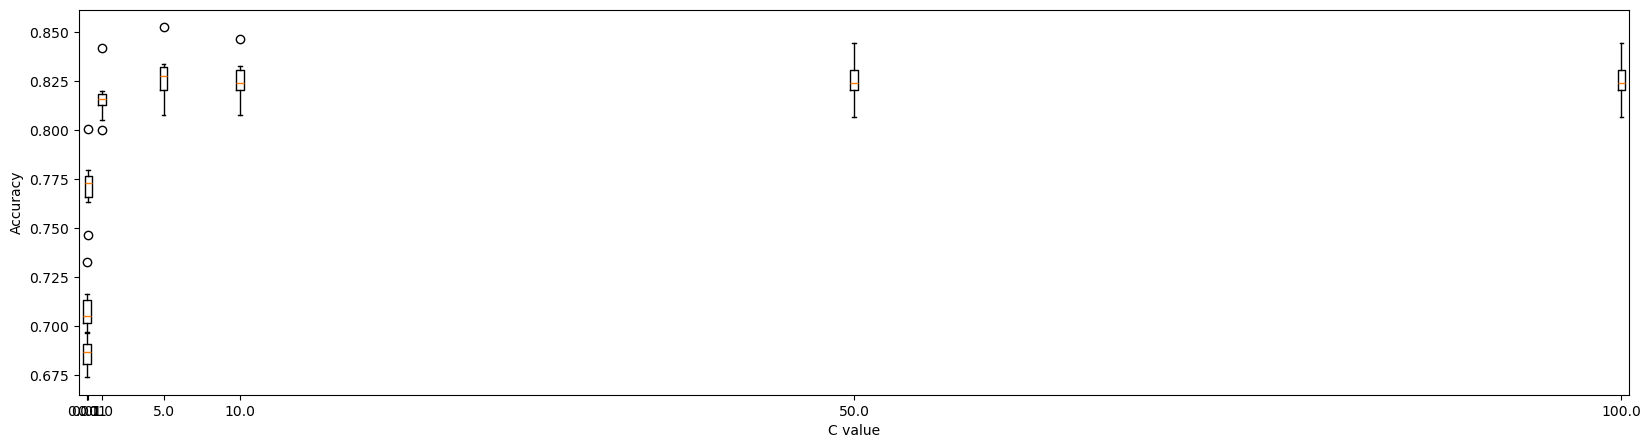

In [11]:
# plotting
import matplotlib.pyplot as plt
plt.figure(figsize=(20,5))
plt.boxplot(x=all_splits_score, positions=c_vals)

plt.xlabel("C value")
plt.ylabel("Accuracy")
plt.show()


In [12]:
# study of gamma
gamma_vals = ["scale", "auto", 0.01, 0.1, 1, 5, 10, 100]
gamma_all_scores = []


for g in gamma_vals:
    clf = SVC(gamma=g)
    scores = cross_val_score(estimator=clf, X=X_train, y=y_train, cv=10)
    all_splits_score.append(scores)
    print(f"gamma = {g} : accuracy = {np.mean(scores):.04f} +/- {np.std(scores):.04f}") #,\tall_support_vectors : {clf.support_vectors_.shape},\tsupport vectors per class : {clf.n_support_.shape}")

gamma = scale : accuracy = 0.8162 +/- 0.0104
gamma = auto : accuracy = 0.5959 +/- 0.0091
gamma = 0.01 : accuracy = 0.5959 +/- 0.0091
gamma = 0.1 : accuracy = 0.6359 +/- 0.0117
gamma = 1 : accuracy = 0.7285 +/- 0.0134
gamma = 5 : accuracy = 0.7595 +/- 0.0110
gamma = 10 : accuracy = 0.7707 +/- 0.0140
gamma = 100 : accuracy = 0.8141 +/- 0.0107


In [15]:
print(len(gamma_all_scores))
print(len(gamma_vals))

0
8


ValueError: List of boxplot statistics and `positions` values must have same the length

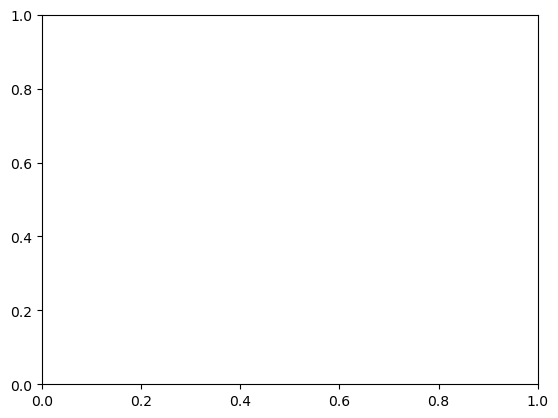

In [14]:
# plotting
plt.figure()
plt.boxplot(x=gamma_all_scores, positions=gamma_vals)

plt.xlabel("gamma value")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
# grid search ?

# Comparing algorithms

Using the best hyper-parameters that you found for each of the algorithms (kNN, Decision Trees, Random Forests, MLP, SVM):

* Re-train the models on the full training set.
* Compare their results on the test set.

In [25]:
# -- Your code here -- #
from sklearn.neighbors import KNeighborsClassifier
from sklearn import tree
from sklearn import ensemble
from sklearn.neural_network import MLPClassifier

models = {
"knn" : KNeighborsClassifier(n_neighbors=5, weights="uniform", p=1),
"dt" : tree.DecisionTreeClassifier(max_depth=10, min_samples_split=2),
"rf" : ensemble.RandomForestClassifier(max_depth=20, min_samples_split=2),
"mlp" : MLPClassifier(hidden_layer_sizes=(100,3)),
"svm" : SVC(C=1, gamma=5),
}

all_models_scores = []

for name, model  in models.items():
    test_scores = []
    for _ in range(5):
        model.fit(X_train, y_train)
        preds = model.predict(X=X_test)
        score = accuracy_score(y_true=y_test, y_pred=preds)
        test_scores.append(score)
    print(f"{name} :\taccuracy = {np.mean(test_scores):.04f} +- {np.std(test_scores):.04f}")
    all_models_scores.append(test_scores)


knn :	accuracy = 0.7797 +- 0.0000
dt :	accuracy = 0.6025 +- 0.0022
rf :	accuracy = 0.7647 +- 0.0047


d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


mlp :	accuracy = 0.6851 +- 0.1779
svm :	accuracy = 0.7557 +- 0.0000


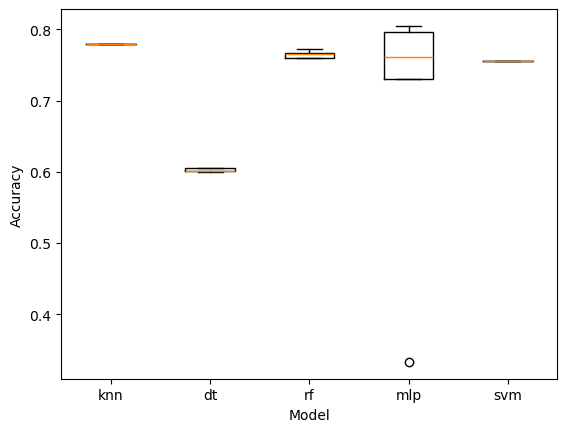

In [36]:
plt.figure()
plt.boxplot(x=all_models_scores, tick_labels=list(models.keys()))

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()